In [1]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("../ml_algorithm_data/powerplant_data.csv")

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
#AT=temperature,V=vaccum,AP=pressure,RH=Humidity,PE=produced energy
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [13]:
import torch
import torch.nn as nn

In [21]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [22]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
test_dataset=TensorDataset(X_test_tensor, y_test_tensor)


In [23]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([7654, 4])
torch.Size([7654, 1])


In [24]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [32]:
#defining our ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
        #first hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),
        #second hidden layer
        nn.Linear(6,6),
        nn.ReLU(),
        #output layer
        nn.Linear(6,1)
    )  
    def forward(self,x):
        return self.model(x)

In [34]:
import torch. optim as optim
model=ANN()
#loss, optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [36]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 18.798096285263696 & val loss = 17.450288772583008
epoch 2/100 ==> train loss = 18.757695811986924 & val loss = 17.548656463623047
epoch 3/100 ==> train loss = 18.800997118155163 & val loss = 17.324853897094727
epoch 4/100 ==> train loss = 18.715729784965514 & val loss = 17.255891799926758
epoch 5/100 ==> train loss = 18.720081196228662 & val loss = 17.33945083618164
epoch 6/100 ==> train loss = 18.79939027428627 & val loss = 17.97997283935547
epoch 7/100 ==> train loss = 18.58934602737427 & val loss = 18.077695846557617
epoch 8/100 ==> train loss = 18.66984076897303 & val loss = 17.4770450592041
epoch 9/100 ==> train loss = 18.68250736196836 & val loss = 17.490854263305664
epoch 10/100 ==> train loss = 18.73544941941897 & val loss = 17.34108543395996
epoch 11/100 ==> train loss = 18.67612270315488 & val loss = 17.172565460205078
epoch 12/100 ==> train loss = 18.771497770150503 & val loss = 17.3094539642334
epoch 13/100 ==> train loss = 18.620763063430786 &

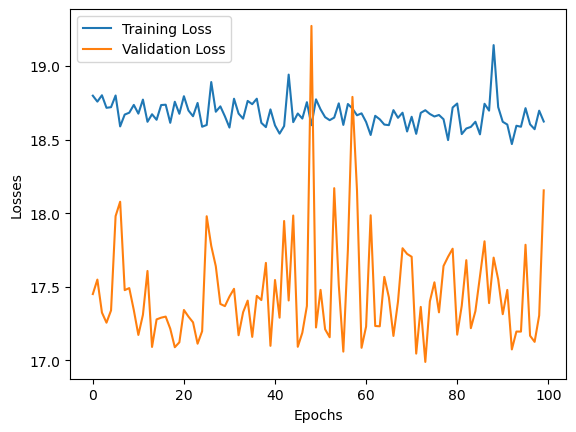

In [38]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()


In [39]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [40]:
# Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 18.26283836364746
Testing MSE: 17.001697540283203


In [42]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9405834543595744
